# Análise dos Resultados — ChangeMamba Reprodução

Análise dos experimentos de reprodução do ChangeMamba.

Antes de executar esse notebook, será necessária ou a existencia dos arquivos "summary.json" abaixo. 

- `original_summary` representa os resultados do artigo original;
- `summary-batches` representa os resultados deste codigo com batches
- `summary` representa os resultado deste codigo sem batches

In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

with open('summary.json', 'r') as f:
    reproduced_raw = json.load(f)

with open('original_summary.json', 'r') as f:
    original_raw = json.load(f)

with open('summary-batches.json', 'r') as f:
    batches_raw = json.load(f)

df_reproduced = pd.DataFrame(reproduced_raw)
df_original = pd.DataFrame(original_raw)
df_batches = pd.DataFrame(batches_raw)

df_reproduced = df_reproduced[df_reproduced['success'] == True].copy()
df_original = df_original[df_original['success'] == True].copy()
df_batches = df_batches[df_batches['success'] == True].copy()

def expand_metrics(df):
    metrics_expanded = pd.json_normalize(df['metrics'])
    return pd.concat([df.drop('metrics', axis=1).reset_index(drop=True), 
                      metrics_expanded.reset_index(drop=True)], axis=1)

df_reproduced = expand_metrics(df_reproduced)
df_original = expand_metrics(df_original)
df_batches = expand_metrics(df_batches)

print(f" Dados carregados com sucesso")
print(f"\n  Registros bem-sucedidos:")
print(f"    - df_reproduced (summary.json): {len(df_reproduced)}")
print(f"    - df_original (original_summary.json): {len(df_original)}")
print(f"    - df_batches (summary-batches.json): {len(df_batches)}")
print(f"\n  Formas:")
print(f"    - df_reproduced: {df_reproduced.shape}")
print(f"    - df_original: {df_original.shape}")
print(f"    - df_batches: {df_batches.shape}")

✓ Dados carregados com sucesso

  Registros bem-sucedidos:
    - df_reproduced (summary.json): 62
    - df_original (original_summary.json): 12
    - df_batches (summary-batches.json): 265

  Formas:
    - df_reproduced: (62, 16)
    - df_original: (12, 14)
    - df_batches: (265, 16)


In [154]:
df_reproduced.sample(5)

,run,timestamp,model,dataset,success,batch,error,Kappa,Fscd,OA,mIoU,SeK,Recall,Precision,F1,IoU
17,1,2026-07-06T13:15:23.055098,MambaBCD_Tiny,WHU,True,0,NaN,0.8014,NaN,0.9894,NaN,NaN,0.7027,0.9470,0.8068,0.6761
28,1,2026-07-06T13:20:55.227494,MambaBCD_Tiny,LEVIR-CD+,True,1,NaN,0.6321,NaN,0.9732,NaN,NaN,0.6009,0.6983,0.6460,0.4771
2,3,2026-07-06T09:36:20.588909,MambaSCD_Base,SECOND,True,0,NaN,0.0049,0.169,0.7936,0.6047,0.0026,NaN,NaN,NaN,NaN
23,1,2026-07-06T13:16:59.065996,MambaBCD_Base,WHU,True,1,NaN,0.7542,NaN,0.9857,NaN,NaN,0.7262,0.8007,0.7616,0.6150
11,1,2026-07-06T13:13:37.720168,MambaBCD_Tiny,SYSU-CD,True,4,NaN,0.6780,NaN,0.8826,NaN,NaN,0.7150,0.7993,0.7548,0.6062


In [155]:
df_original.sample(5)

,run,timestamp,model,dataset,success,batch,Recall,Precision,OA,F1,IoU,Kappa,mIoU,SeK
3,1,2026-07-06T13:16:40.543445,MambaBCD_Base,WHU,True,0,0.9223,0.9618,0.9958,0.9419,0.8902,0.9398,NaN,NaN
5,1,2026-07-06T13:27:13.853147,MambaBCD_Small,LEVIR-CD+,True,0,0.8649,0.8917,0.9902,0.8781,0.7827,0.8730,NaN,NaN
6,1,2026-07-06T13:37:38.971779,MambaSCD_Base,SECOND,True,0,NaN,NaN,0.9036,0.5532,NaN,NaN,0.7368,0.2292
9,1,2026-07-06T14:03:09.345890,MambaBCD_Small,WHU,True,0,0.9229,0.9590,0.9957,0.9406,0.8879,0.9384,NaN,NaN
1,1,2026-07-06T13:13:56.234120,MambaBCD_Base,SYSU-CD,True,0,0.8031,0.8611,0.9230,0.8311,0.7110,0.7813,NaN,NaN


In [156]:
df_batches.sample(5)

,run,timestamp,model,dataset,success,batch,error,Recall,Precision,OA,F1,IoU,Kappa,Fscd,mIoU,SeK
112,3,2026-06-22T10:21:53.627076,MambaBCD_Tiny,LEVIR-CD+,True,2,NaN,0.6009,0.6983,0.9732,0.6460,0.4771,0.6321,NaN,NaN,NaN
256,2,2026-06-27T10:05:12.655768,MambaSCD_Tiny,SECOND,True,3,NaN,NaN,NaN,0.7973,NaN,NaN,0.1108,0.3268,0.6502,0.0648
47,3,2026-06-21T21:26:49.055460,MambaBCD_Base,SYSU-CD,True,4,NaN,0.2680,0.8965,0.8163,0.4127,0.2600,0.3395,NaN,NaN,NaN
65,1,2026-06-21T21:30:51.625046,MambaBCD_Tiny,WHU,True,3,NaN,0.7860,0.9405,0.9907,0.8564,0.7488,0.8516,NaN,NaN,NaN
237,3,2026-06-27T09:50:13.535934,MambaSCD_Base,SECOND,True,4,NaN,NaN,NaN,0.7837,NaN,NaN,NaN,0.1556,0.5996,NaN


#### Diferença entre metrica F1 para o artigo original e a reprodução

In [157]:
df_merged = df_original.merge(df_reproduced, on=['model', 'dataset'], suffixes=('_df1', '_df2'))

df = df_merged.dropna(subset=['F1_df1'])
df = df.dropna(subset=['F1_df2'])
df['diferenca'] = df['F1_df1'] - df['F1_df2']

print(f"Diferença média: {df['diferenca'].mean()}")


Diferença média: 0.19426666666666656


In [158]:
q0 = df['diferenca'].quantile(0)  # 1º quartil (Q1)
q1 = df['diferenca'].quantile(0.25)  # 1º quartil (Q1)
q2 = df['diferenca'].quantile(0.50)  # Mediana (Q2)
q3 = df['diferenca'].quantile(0.75)  # 3º quartil (Q3)

print(f"75% dos valores residem entre {q0:.4f} e {q3:.4f} pontos")
print(f"50% dos valores residem entre {q1:.4f} e {q3:.4f} pontos")

75% dos valores residem entre 0.0581 e 0.2344 pontos
50% dos valores residem entre 0.1265 e 0.2344 pontos


In [159]:
colunas_metricas = ['Kappa', 'Fscd', 'OA', 'mIoU', 'SeK', 'Recall', 'Precision', 'F1', 'IoU']

df_batches_media = df_batches.groupby(['model', 'dataset'])[colunas_metricas].mean()

print(df_batches_media)


                             Kappa     Fscd       OA     mIoU      SeK  \
model          dataset                                                   
MambaBCD_Base  LEVIR-CD+  0.696200      NaN  0.97910      NaN      NaN   
               SYSU-CD    0.367320      NaN  0.82566      NaN      NaN   
               WHU        0.782120      NaN  0.98506      NaN      NaN   
MambaBCD_Small LEVIR-CD+  0.587500      NaN  0.97510      NaN      NaN   
               SYSU-CD    0.529360      NaN  0.85268      NaN      NaN   
               WHU        0.850700      NaN  0.99080      NaN      NaN   
MambaBCD_Tiny  LEVIR-CD+  0.632100      NaN  0.97320      NaN      NaN   
               SYSU-CD    0.695960      NaN  0.89254      NaN      NaN   
               WHU        0.841360      NaN  0.98986      NaN      NaN   
MambaSCD_Base  SECOND     0.008125  0.16918  0.78978  0.60138  0.00435   
MambaSCD_Tiny  SECOND     0.119000  0.33328  0.79882  0.64898  0.06946   

                           Recall  Pr

In [160]:
df_batches_media = df_batches.groupby(['model', 'dataset'])[colunas_metricas].mean().reset_index()

print(df_batches_media)


             model    dataset     Kappa     Fscd       OA     mIoU      SeK  \
0    MambaBCD_Base  LEVIR-CD+  0.696200      NaN  0.97910      NaN      NaN   
1    MambaBCD_Base    SYSU-CD  0.367320      NaN  0.82566      NaN      NaN   
2    MambaBCD_Base        WHU  0.782120      NaN  0.98506      NaN      NaN   
3   MambaBCD_Small  LEVIR-CD+  0.587500      NaN  0.97510      NaN      NaN   
4   MambaBCD_Small    SYSU-CD  0.529360      NaN  0.85268      NaN      NaN   
5   MambaBCD_Small        WHU  0.850700      NaN  0.99080      NaN      NaN   
6    MambaBCD_Tiny  LEVIR-CD+  0.632100      NaN  0.97320      NaN      NaN   
7    MambaBCD_Tiny    SYSU-CD  0.695960      NaN  0.89254      NaN      NaN   
8    MambaBCD_Tiny        WHU  0.841360      NaN  0.98986      NaN      NaN   
9    MambaSCD_Base     SECOND  0.008125  0.16918  0.78978  0.60138  0.00435   
10   MambaSCD_Tiny     SECOND  0.119000  0.33328  0.79882  0.64898  0.06946   

     Recall  Precision       F1      IoU  
0   0.61

#### Diferença entre metrica F1 para o artigo original e as amostras

In [161]:
df_merged_batches = df_original.merge(df_batches_media, on=['model', 'dataset'], suffixes=('_df1', '_df2'))

df_merged_batches = df_merged_batches.dropna(subset=['F1_df1'])
df_merged_batches = df_merged_batches.dropna(subset=['F1_df2'])

df_merged_batches['diferenca'] = df_merged_batches['F1_df1'] - df_merged_batches['F1_df2']
df_merged_batches_clean = df_merged_batches.dropna(subset=['diferenca'])

print(f"Diferença média: {df_merged_batches_clean['diferenca'].mean()}")

Diferença média: 0.18539333333333335


/var/folders/5g/yp2hy0_s75l7pgywmx1rf0lw0000gn/T/ipykernel_89233/722608366.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df['diferenca'], vert=True)


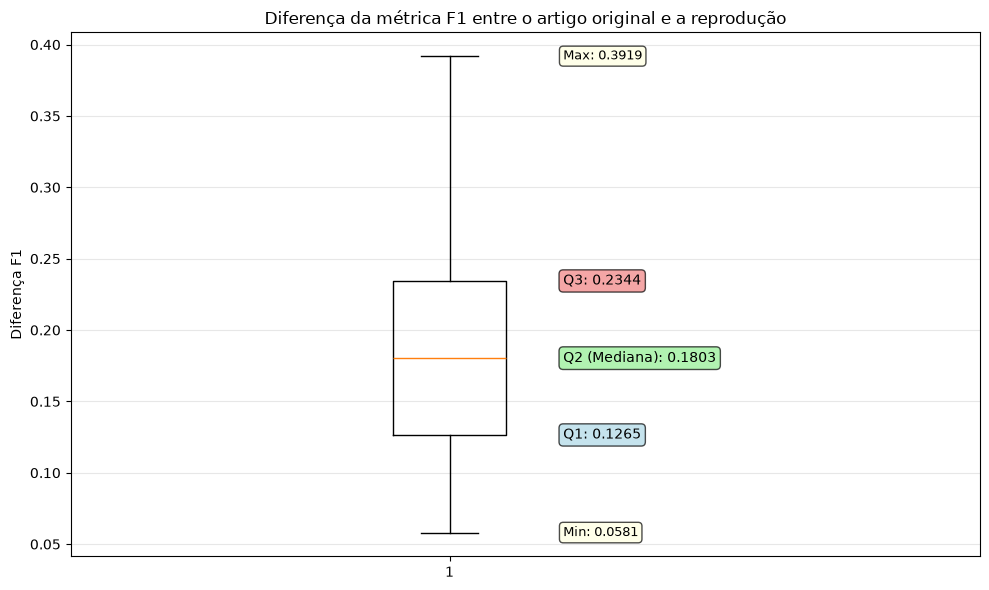

In [162]:
# Box plot com valores dos quartis
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(df['diferenca'], vert=True)

# Calcular quartis
q1 = df['diferenca'].quantile(0.25)
q2 = df['diferenca'].quantile(0.50)
q3 = df['diferenca'].quantile(0.75)
min_val = df['diferenca'].min()
max_val = df['diferenca'].max()

# Adicionar valores no gráfico
ax.text(1.15, q1, f'Q1: {q1:.4f}', va='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
ax.text(1.15, q2, f'Q2 (Mediana): {q2:.4f}', va='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
ax.text(1.15, q3, f'Q3: {q3:.4f}', va='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))
ax.text(1.15, min_val, f'Min: {min_val:.4f}', va='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))
ax.text(1.15, max_val, f'Max: {max_val:.4f}', va='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

ax.set_title('Diferença da métrica F1 entre o artigo original e a reprodução')
ax.set_ylabel('Diferença F1')
ax.grid(axis='y', alpha=0.3)
ax.set_xlim(0.5, 1.7)
plt.tight_layout()
plt.show()

/var/folders/5g/yp2hy0_s75l7pgywmx1rf0lw0000gn/T/ipykernel_89233/2790160797.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot([data_repr, data_batch], tick_labels=['Reprodução', 'Amostras (Média)'], vert=True, patch_artist=True)


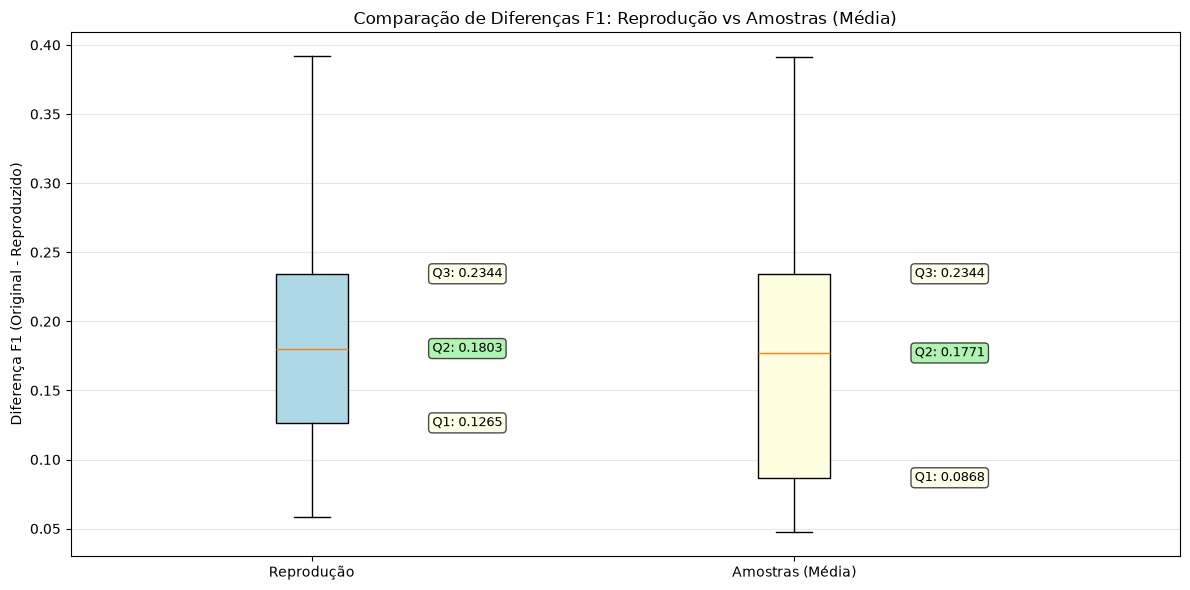

In [163]:
# Boxplot com duas caixas lado a lado: Reprodução vs Batches
fig, ax = plt.subplots(figsize=(12, 6))

# Preparar dados
data_repr = df['diferenca'].values
data_batch = df_merged_batches_clean['diferenca'].values

# Criar boxplot
bp = ax.boxplot([data_repr, data_batch], tick_labels=['Reprodução', 'Amostras (Média)'], vert=True, patch_artist=True)

# Colorir as caixas
colors = ['lightblue', 'lightyellow']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Calcular quartis para Reprodução
q1_repr = np.quantile(data_repr, 0.25)
q2_repr = np.quantile(data_repr, 0.50)
q3_repr = np.quantile(data_repr, 0.75)

# Calcular quartis para Batches
q1_batch = np.quantile(data_batch, 0.25)
q2_batch = np.quantile(data_batch, 0.50)
q3_batch = np.quantile(data_batch, 0.75)

# Adicionar valores para Reprodução (posição x = 1)
ax.text(1.25, q1_repr, f'Q1: {q1_repr:.4f}', va='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))
ax.text(1.25, q2_repr, f'Q2: {q2_repr:.4f}', va='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
ax.text(1.25, q3_repr, f'Q3: {q3_repr:.4f}', va='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

# Adicionar valores para Batches (posição x = 2)
ax.text(2.25, q1_batch, f'Q1: {q1_batch:.4f}', va='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))
ax.text(2.25, q2_batch, f'Q2: {q2_batch:.4f}', va='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
ax.text(2.25, q3_batch, f'Q3: {q3_batch:.4f}', va='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

ax.set_ylabel('Diferença F1 (Original - Reproduzido)')
ax.set_title('Comparação de Diferenças F1: Reprodução vs Amostras (Média)')
ax.grid(axis='y', alpha=0.3)
ax.set_xlim(0.5, 2.8)
plt.tight_layout()
plt.show()

In [207]:
columns = ["Recall", "Precision", "OA", "F1", "IoU", "Kappa", "mIoU", "SeK"]
dfs = [{"label": "Reproduzido", "df": df_reproduced}, {"label": "Média (Amostras)", "df": df_batches_media}]


for df in dfs:

    df_merged = df_original.merge(df.get("df"), on=["model", "dataset"], suffixes=("_og", "_rep"))

    for col in columns:
        df_merged[col] = df_merged[f"{col}_rep"] - df_merged[f"{col}_og"]

    final_df = df_merged[["model", "dataset"] + columns]

    for col in columns:
        print(f"Diferença média ({df.get("label")}) {col}: {final_df[col].mean():.4f};")

final_df

Diferença média (Reproduzido) Recall: -0.2612;
Diferença média (Reproduzido) Precision: -0.0579;
Diferença média (Reproduzido) OA: -0.0528;
Diferença média (Reproduzido) F1: -0.1943;
Diferença média (Reproduzido) IoU: -0.2553;
Diferença média (Reproduzido) Kappa: -0.2075;
Diferença média (Reproduzido) mIoU: -0.1187;
Diferença média (Reproduzido) SeK: -0.2050;
Diferença média (Média (Amostras)) Recall: -0.2475;
Diferença média (Média (Amostras)) Precision: -0.0579;
Diferença média (Média (Amostras)) OA: -0.0430;
Diferença média (Média (Amostras)) F1: -0.1854;
Diferença média (Média (Amostras)) IoU: -0.2428;
Diferença média (Média (Amostras)) Kappa: -0.1968;
Diferença média (Média (Amostras)) mIoU: -0.1099;
Diferença média (Média (Amostras)) SeK: -0.1881;


,model,dataset,Recall,Precision,OA,F1,IoU,Kappa,mIoU,SeK
0,MambaBCD_Tiny,SYSU-CD,-0.06342,-0.02884,-0.02106,-0.04744,-0.06474,-0.06084,NaN,NaN
1,MambaBCD_Base,SYSU-CD,-0.51238,0.04228,-0.09734,-0.39142,-0.42896,-0.41398,NaN,NaN
2,MambaBCD_Tiny,WHU,-0.15196,-0.00304,-0.00534,-0.08678,-0.14060,-0.08944,NaN,NaN
3,MambaBCD_Base,WHU,-0.16234,-0.13850,-0.01074,-0.15206,-0.23616,-0.15768,NaN,NaN
4,MambaBCD_Tiny,LEVIR-CD+,-0.27170,-0.18990,-0.01710,-0.23440,-0.30920,-0.24320,NaN,NaN
5,MambaBCD_Small,LEVIR-CD+,-0.40880,-0.01910,-0.01510,-0.27900,-0.35510,-0.28550,NaN,NaN
6,MambaSCD_Base,SECOND,NaN,NaN,-0.11382,NaN,NaN,NaN,-0.13542,-0.22485
7,MambaSCD_Tiny,SECOND,NaN,NaN,-0.10558,NaN,NaN,NaN,-0.08432,-0.15134
8,MambaBCD_Small,WHU,-0.10576,-0.06078,-0.00490,-0.08516,-0.13960,-0.08770,NaN,NaN
9,MambaBCD_Small,SYSU-CD,-0.29364,-0.05670,-0.07082,-0.21518,-0.26490,-0.25004,NaN,NaN


In [212]:
columns = ["Recall", "Precision", "OA", "F1", "IoU", "Kappa", "mIoU", "SeK"]
dfs = [{"label": "Reproduzido", "df": df_reproduced}, {"label": "Média (Amostras)", "df": df_batches_media}]

dfs_final = []
for df in dfs:
    df_merged = df_original.merge(df.get("df"), on=["model", "dataset"], suffixes=("_og", "_rep"))

    for col in columns:
        df_merged[col] = df_merged[f"{col}_rep"] - df_merged[f"{col}_og"]

    # Agrupar por model + dataset e calcular a MÉDIA
    df_grouped = df_merged.groupby(["model", "dataset"])[columns].mean().reset_index()
    dfs_final.append(df_grouped)

    print(f"\n{df.get('label')}:")
    print(df_grouped)



Reproduzido:
             model    dataset  Recall  Precision      OA      F1     IoU  \
0    MambaBCD_Base  LEVIR-CD+ -0.2578    -0.0668 -0.0115 -0.1771 -0.2455   
1    MambaBCD_Base    SYSU-CD -0.5141     0.0536 -0.1095 -0.3919 -0.4296   
2    MambaBCD_Base        WHU -0.1961    -0.1611 -0.0101 -0.1803 -0.2752   
3   MambaBCD_Small  LEVIR-CD+ -0.4088    -0.0191 -0.0151 -0.2790 -0.3551   
4   MambaBCD_Small    SYSU-CD -0.3004    -0.0452 -0.0785 -0.2171 -0.2669   
5   MambaBCD_Small        WHU -0.1040    -0.0611 -0.0043 -0.0840 -0.1388   
6    MambaBCD_Tiny  LEVIR-CD+ -0.2717    -0.1899 -0.0171 -0.2344 -0.3092   
7    MambaBCD_Tiny    SYSU-CD -0.0809    -0.0313 -0.0310 -0.0581 -0.0786   
8    MambaBCD_Tiny        WHU -0.2167    -0.0006 -0.0058 -0.1265 -0.1988   
9    MambaSCD_Base     SECOND     NaN        NaN -0.1100     NaN     NaN   
10   MambaSCD_Tiny     SECOND     NaN        NaN -0.1079     NaN     NaN   

     Kappa    mIoU     SeK  
0  -0.1829     NaN     NaN  
1  -0.4195     

In [215]:
dfs_final[1]

,model,dataset,Recall,Precision,OA,F1,IoU,Kappa,mIoU,SeK
0,MambaBCD_Base,LEVIR-CD+,-0.25780,-0.06680,-0.01150,-0.17710,-0.24550,-0.18290,NaN,NaN
1,MambaBCD_Base,SYSU-CD,-0.51238,0.04228,-0.09734,-0.39142,-0.42896,-0.41398,NaN,NaN
2,MambaBCD_Base,WHU,-0.16234,-0.13850,-0.01074,-0.15206,-0.23616,-0.15768,NaN,NaN
3,MambaBCD_Small,LEVIR-CD+,-0.40880,-0.01910,-0.01510,-0.27900,-0.35510,-0.28550,NaN,NaN
4,MambaBCD_Small,SYSU-CD,-0.29364,-0.05670,-0.07082,-0.21518,-0.26490,-0.25004,NaN,NaN
5,MambaBCD_Small,WHU,-0.10576,-0.06078,-0.00490,-0.08516,-0.13960,-0.08770,NaN,NaN
6,MambaBCD_Tiny,LEVIR-CD+,-0.27170,-0.18990,-0.01710,-0.23440,-0.30920,-0.24320,NaN,NaN
7,MambaBCD_Tiny,SYSU-CD,-0.06342,-0.02884,-0.02106,-0.04744,-0.06474,-0.06084,NaN,NaN
8,MambaBCD_Tiny,WHU,-0.15196,-0.00304,-0.00534,-0.08678,-0.14060,-0.08944,NaN,NaN
9,MambaSCD_Base,SECOND,NaN,NaN,-0.11382,NaN,NaN,NaN,-0.13542,-0.22485


In [217]:
columns = ["Recall", "Precision", "OA", "F1", "IoU", "Kappa", "mIoU", "SeK"]

# Calcular estatísticas por model + dataset
grouped = df_batches.groupby(['model', 'dataset'])[columns]

results = []
for (model, dataset), group in grouped:
    row = {'model': model, 'dataset': dataset}
    for col in columns:
        values = group[col].dropna()
        if len(values) > 0:
            média = values.mean()
            std = values.std()
            cv = (std / média * 100) if média != 0 else 0
            amplitude = values.max() - values.min()
            
            row[f'{col}_média'] = round(média, 4)
            row[f'{col}_std'] = round(std, 4)
            row[f'{col}_CV_%'] = round(cv, 2)
            row[f'{col}_amplitude'] = round(amplitude, 4)
    
    results.append(row)

stats_final = pd.DataFrame(results)
stats_final


,model,dataset,Recall_média,Recall_std,Recall_CV_%,Recall_amplitude,Precision_média,Precision_std,Precision_CV_%,Precision_amplitude,...,Kappa_CV_%,Kappa_amplitude,mIoU_média,mIoU_std,mIoU_CV_%,mIoU_amplitude,SeK_média,SeK_std,SeK_CV_%,SeK_amplitude
0,MambaBCD_Base,LEVIR-CD+,0.6179,0.0000,0.00,0.0000,0.8256,0.0000,0.00,0.0000,...,0.00,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,MambaBCD_Base,SYSU-CD,0.2907,0.0178,6.12,0.0503,0.9034,0.0139,1.54,0.0394,...,6.08,0.0622,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,MambaBCD_Base,WHU,0.7600,0.0464,6.11,0.1198,0.8233,0.0311,3.78,0.0835,...,4.61,0.1061,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MambaBCD_Small,LEVIR-CD+,0.4561,0.0000,0.00,0.0000,0.8726,0.0000,0.00,0.0000,...,0.00,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,MambaBCD_Small,SYSU-CD,0.4889,0.0137,2.81,0.0319,0.8232,0.0180,2.19,0.0418,...,1.34,0.0153,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,MambaBCD_Small,WHU,0.8171,0.0412,5.05,0.1063,0.8982,0.0107,1.19,0.0321,...,3.25,0.0717,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,MambaBCD_Tiny,LEVIR-CD+,0.6009,0.0000,0.00,0.0000,0.6983,0.0000,0.00,0.0000,...,0.00,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,MambaBCD_Tiny,SYSU-CD,0.7325,0.0119,1.62,0.0301,0.8018,0.0059,0.74,0.0160,...,1.08,0.0169,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,MambaBCD_Tiny,WHU,0.7674,0.0292,3.80,0.0853,0.9446,0.0060,0.64,0.0152,...,2.20,0.0542,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,MambaSCD_Base,SECOND,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,46.10,0.0095,0.6014,0.0023,0.38,0.0061,0.0044,0.002,46.35,0.0051


In [ ]:
stats_final.to_csv('stats_final.csv', index=False)
print("Arquivo salvo em: stats_final.csv")


✓ Arquivo salvo em: stats_final.csv
